In [5]:
import pandas as pd
import numpy as np
import re
import emoji
import fasttext
from langdetect import detect
from wordcloud import WordCloud

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style('whitegrid')

In [6]:
df = pd.read_csv('MASTER_RAW_kenya_fintech.csv') #loading dataset
df.head() #preview of the first 5 rows of the dataset

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa
1,acd5c061-de13-474b-8645-f628044f2a50,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,NaN,mpesa


- Understanding dataset size helps estimate the scale of customer feedback being analyzed. A larger dataset improves the reliability of insights and model predictions.

In [7]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(53507, 12)


To identify available features in the dataset, ensuring that important fields such as review text, ratings, and app names are present for analysis.

In [8]:
df.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion', 'app_name'],
      dtype='object')

In [9]:
print('....Missing values per column....')
df.isnull().sum() #checking missing values


....Missing values per column....


reviewId                    0
userName                    0
userImage                   0
content                     1
score                       0
thumbsUpCount               0
reviewCreatedVersion     6164
at                          0
replyContent            29574
repliedAt               29574
appVersion               6164
app_name                    0
dtype: int64

To check apps in the dataset

In [10]:
df['app_name'].unique()

array(['mpesa', 'mysafaricom', 'kcb', 'equity', 'tala', 'branch'],
      dtype=object)

1. Count Reviews Per App

- Review volume helps measure customer engagement and app popularity. High review counts may indicate a large customer base or increased customer concern.

app_name
mpesa          10000
mysafaricom    10000
equity         10000
tala           10000
branch         10000
kcb             3507
Name: count, dtype: int64


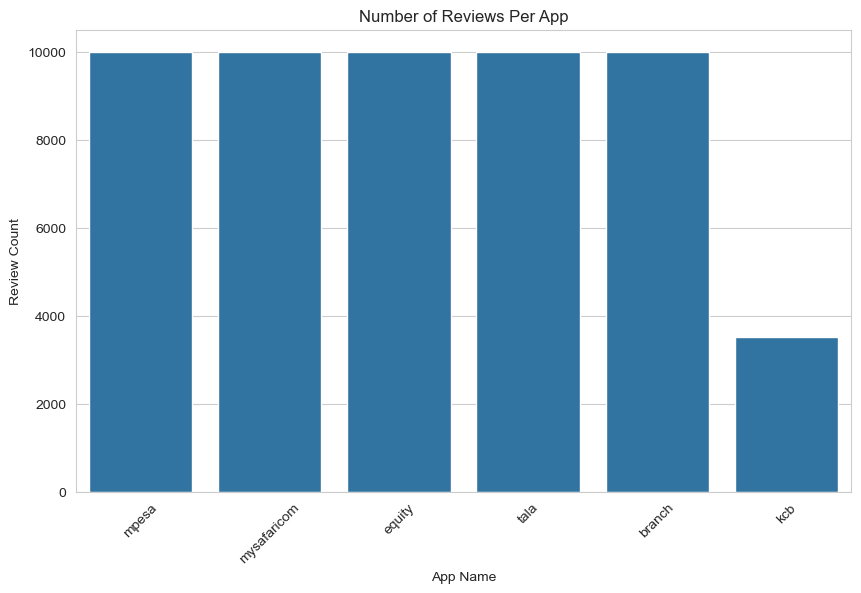

In [11]:
reviews_per_app = df['app_name'].value_counts()

print(reviews_per_app)

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='app_name',
    order=df['app_name'].value_counts().index
)

plt.title('Number of Reviews Per App')
plt.xlabel('App Name')
plt.ylabel('Review Count')

plt.xticks(rotation=45)

plt.show()

2. Analyzing Star Rating Distribution
- Star ratings provide a direct measure of customer satisfaction. This section evaluates the distribution of positive and negative user experiences.

score
1     9269
2     1771
3     2170
4     4753
5    35544
Name: count, dtype: int64


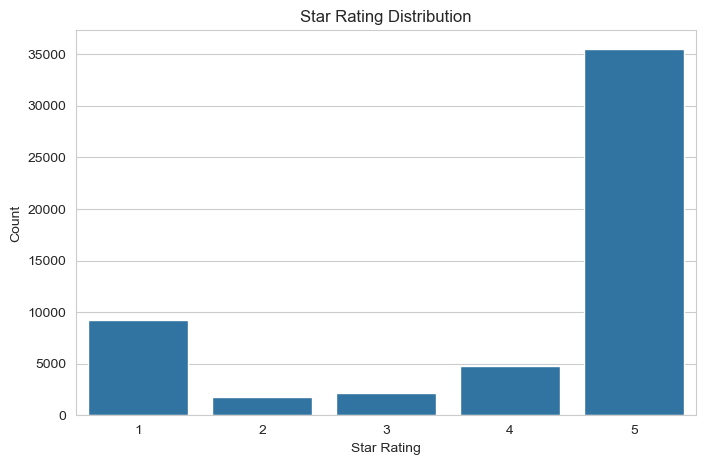

In [12]:
print(df['score'].value_counts().sort_index())
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='score'
)

plt.title('Star Rating Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Count')

plt.show()

The distribution of star ratings across the dataset, revealing a significant positive bias with 5-star ratings being the most frequent by a large margin (over 35,000 counts). While there is a secondary spike in 1-star reviews representing dissatisfied users, the "middle" ground of 2, 3, and 4-star ratings is notably underrepresented. This indicates a class imbalance is a critical observation, as the model will be heavily exposed to extreme opinions rather than neutral feedback.

3. Star Ratings Per App
- This section compares rating behavior across different fintech applications to identify apps with higher complaint levels or customer satisfaction.

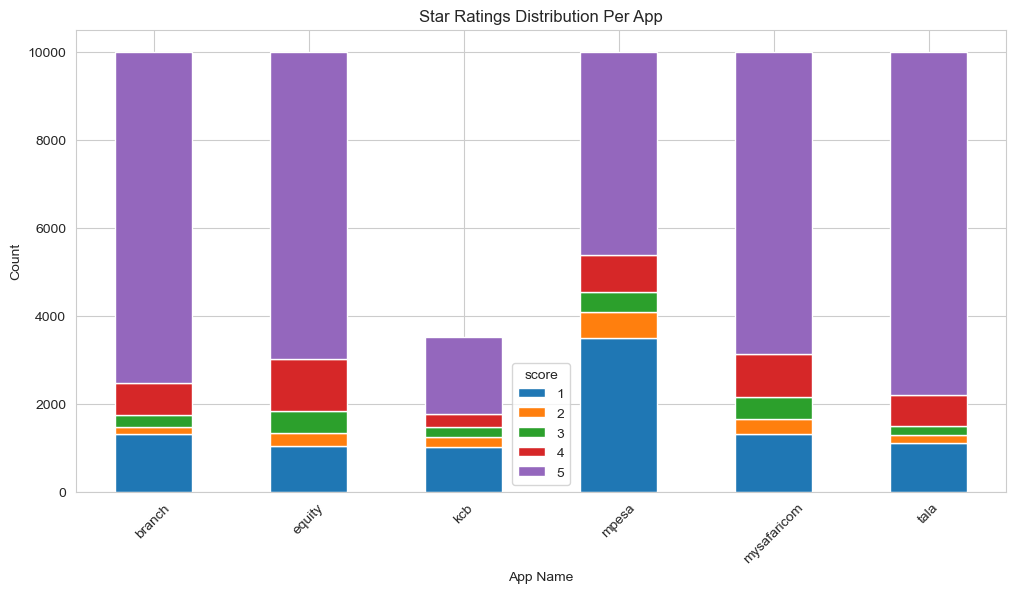

In [13]:
ratings_by_app = pd.crosstab(
    df['app_name'],
    df['score']
)

ratings_by_app.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Star Ratings Distribution Per App')
plt.xlabel('App Name')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

While most apps are dominated by 5-star reviews, user sentiment varies significantly across the platforms. The mpesa app stands out for having the highest volume of 1-star ratings, suggesting a higher level of user friction or technical dissatisfaction compared to its peers. Apps like branch and tala show a much larger proportion of 5-star reviews, indicating a generally more favorable reception within this specific dataset.

4. Review Length Feature (based on Character Length)

- Review length reflects complaint severity or customer engagement. Longer reviews often contain detailed complaints or service explanations.

In [14]:
df['review_length'] = df['content'].str.len()

df[['content', 'review_length']].head()

,content,review_length
0,"The app still has issues on OTP, because I hav...",311.0
1,si everytime nitakuwa na bundles za ku check m...,196.0
2,this is the stupidest app ever from saf. the w...,50.0
3,Life must go on without this useless app. It u...,125.0
4,the upgrade is terrible,23.0


5. Review Length Distribution

- How detailed customer feedback tends to be across the dataset.

Average Review Length:
42.62


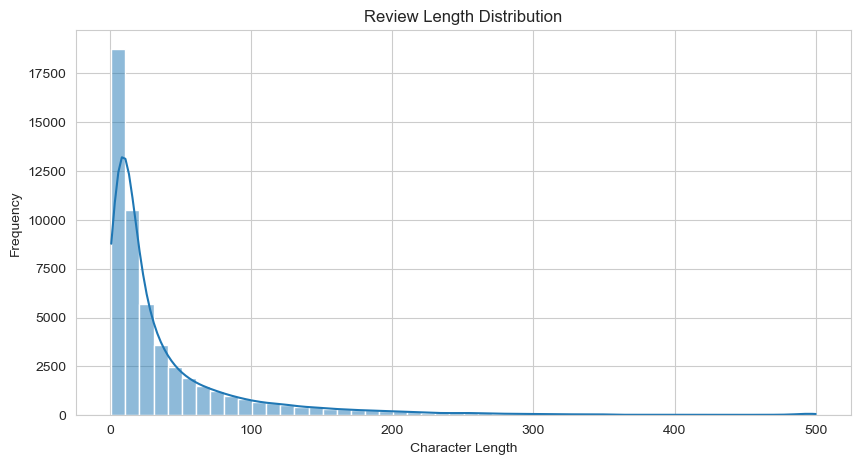

In [15]:
average_review_length = df['review_length'].mean()

print("Average Review Length:")

print(round(average_review_length, 2))
plt.figure(figsize=(10,5))

sns.histplot(
    df['review_length'],
    bins=50,
    kde=True
)

plt.title('Review Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Frequency')

plt.show()

6. Word count distrubution

In [16]:
df['word_count'] = df['content'].fillna('').apply(lambda x: len(str(x).split()))

print(df[['content', 'word_count']].head())

                                             content  word_count
0  The app still has issues on OTP, because I hav...          59
1  si everytime nitakuwa na bundles za ku check m...          42
2  this is the stupidest app ever from saf. the w...          10
3  Life must go on without this useless app. It u...          27
4                            the upgrade is terrible           4


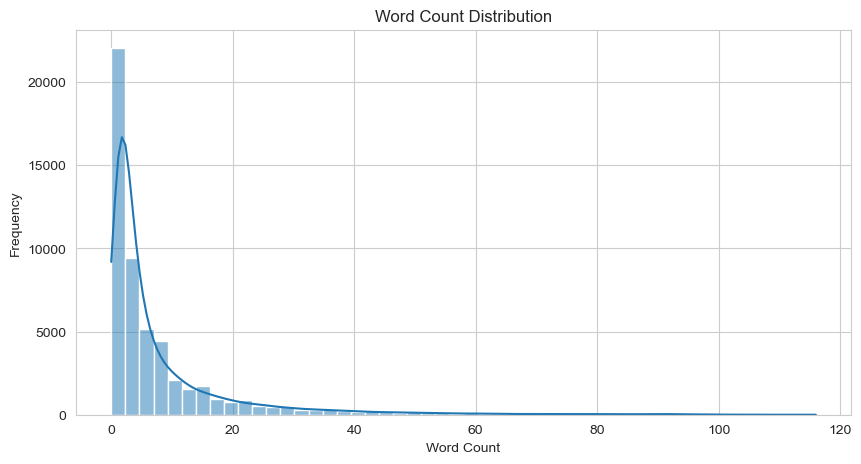

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['word_count'],
    bins=50,
    kde=True
)

plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.show()

7. Average word count
- summarizes the typical size of customer reviews within the dataset.

In [18]:
average_word_count = df['word_count'].mean()

print("Average Word Count:")

print(round(average_word_count, 2))

Average Word Count:
8.0


8. Summary statistics

In [19]:
summary_stats = df[[
    'score',
    'review_length',
    'word_count'
]].describe()

summary_stats

,score,review_length,word_count
count,53507.000000,53506.000000,53507.000000
mean,4.037846,42.620286,7.998916
std,1.547552,66.305219,12.263332
min,1.000000,1.000000,0.000000
25%,4.000000,8.000000,2.000000
50%,5.000000,17.000000,3.000000
75%,5.000000,46.000000,9.000000
max,5.000000,500.000000,116.000000


9. Average Review Length by Rating

- This analysis investigates whether level of dissatisfied influence length of reviews.

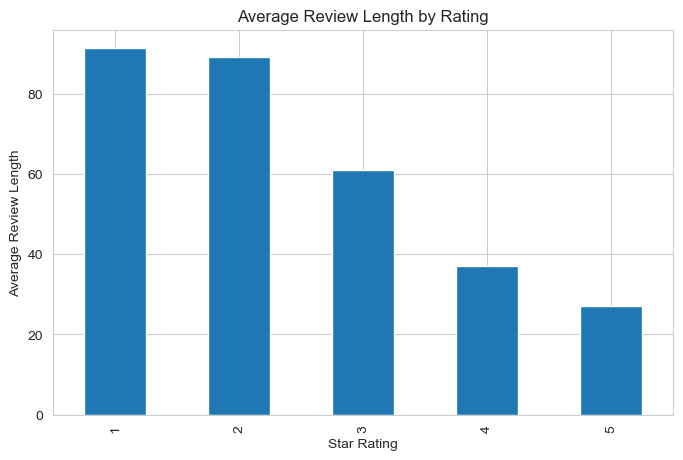

In [20]:
avg_length_by_rating = df.groupby('score')[
    'review_length'
].mean()

plt.figure(figsize=(8,5))

avg_length_by_rating.plot(kind='bar')

plt.title('Average Review Length by Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Review Length')

plt.show()

#### Key Insights
- Most important findings from the dataset.

In [21]:
print("- Most reviewed app:")
print(df['app_name'].value_counts().idxmax())

print("- Most common star rating:")
print(df['score'].mode()[0])

print("- Average review length:")
print(round(df['review_length'].mean(), 2))

print("- Average word count:")
print(round(df['word_count'].mean(), 2))

- Most reviewed app:
mpesa
- Most common star rating:
5
- Average review length:
42.62
- Average word count:
8.0


# Additional Distribution Visualizations

This section provides deeper visualization analysis using histograms and box plots to better understand rating and review distributions.

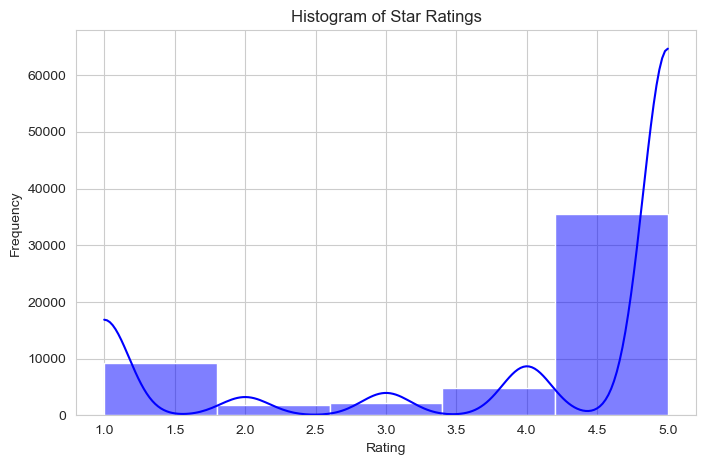

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['score'],
    bins=5,
    kde=True,
    color='blue'
)

plt.title('Histogram of Star Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.show()

## Boxplot of Ratings

This visualization identifies the spread and concentration of app ratings.

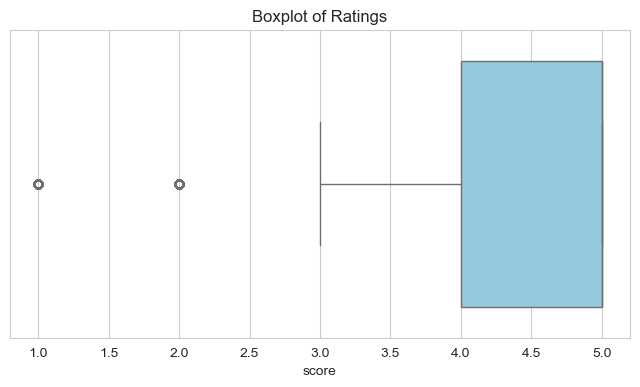

In [23]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df['score'],
    color='skyblue'
)

plt.title('Boxplot of Ratings')

plt.show()

## Histogram of Review Length

This histogram shows how review lengths are distributed across the dataset.

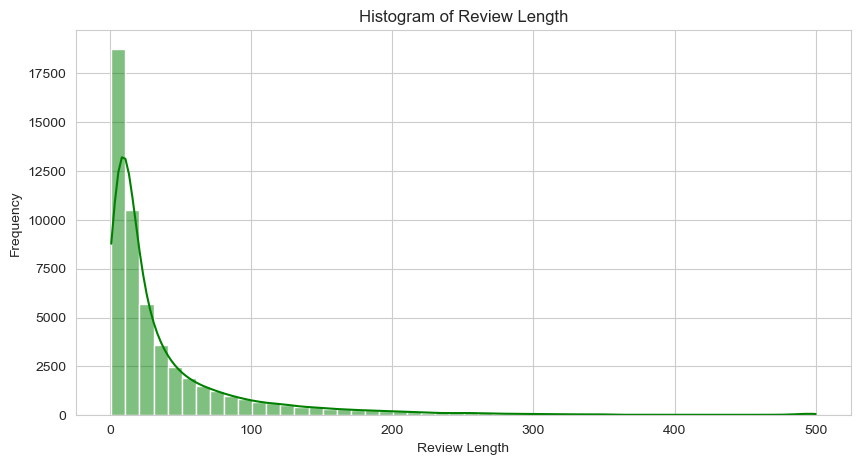

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['review_length'],
    bins=50,
    kde=True,
    color='green'
)

plt.title('Histogram of Review Length')
plt.xlabel('Review Length')
plt.ylabel('Frequency')

plt.show()

## Boxplot of Review Length

This boxplot helps identify outliers and unusually long reviews.

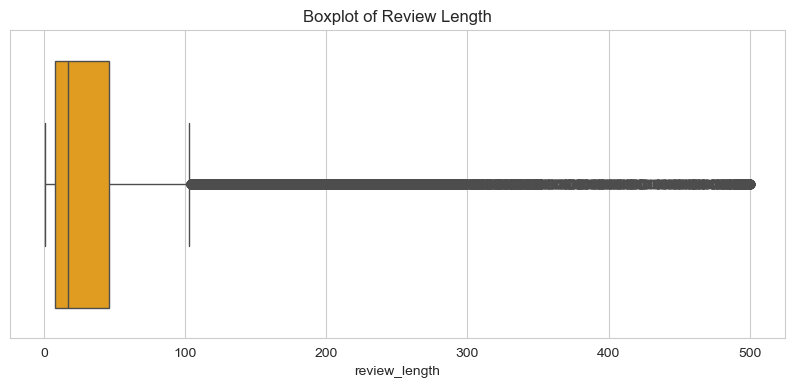

In [25]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['review_length'],
    color='orange'
)

plt.title('Boxplot of Review Length')

plt.show()

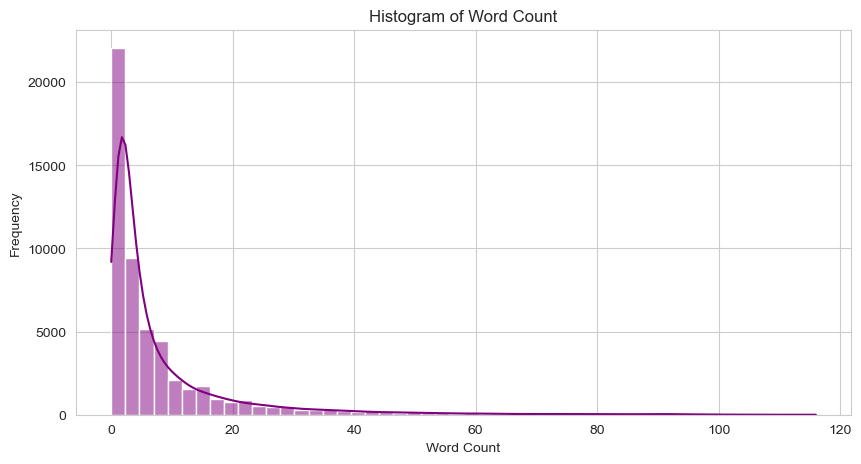

In [26]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['word_count'],
    bins=50,
    kde=True,
    color='purple'
)

plt.title('Histogram of Word Count')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.show()

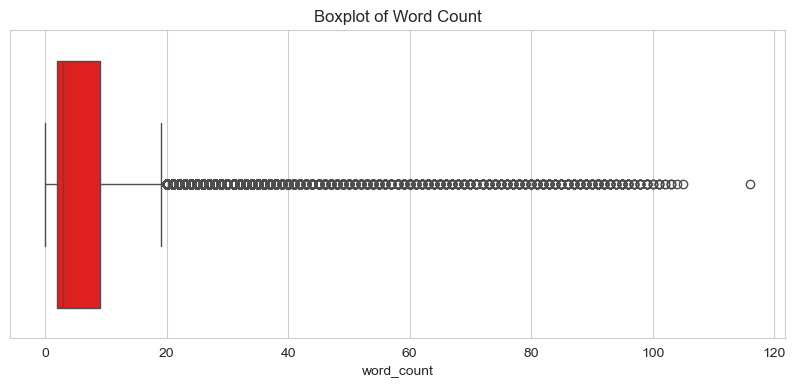

In [27]:
plt.figure(figsize=(10,4))

sns.boxplot(
    x=df['word_count'],
    color='red'
)

plt.title('Boxplot of Word Count')

plt.show()

# Visualization Insights

- Ratings are heavily concentrated around higher scores.
- Review lengths are positively skewed, with a few very long reviews acting as outliers.
- Word count distributions show that most users leave short reviews.
- Boxplots clearly highlight variability and extreme review behaviors.

These visualizations improve understanding of customer feedback patterns before preprocessing and modelling.

 ## Inspecting raw text ##

In [28]:
print(df['content'].sample(10))


41918    I paid my loan a long time ago but three years...
36486                                        Unproblematic
17731                                                 good
27852                                                 good
13592                                            excellent
23675    I once used this app bt when I tried installin...
50811                                                 good
21016                                                 Good
16889    the app keeps on logging me out and the code i...
51299    I had a very disappointing experience with the...
Name: content, dtype: object


### Text Inspection Observations

From the sampled reviews:

-Most reviews are short and concise (e.g., "good", "superb", "perfect").

-A portion of reviews contain **informal language and typos** (e.g., "pefect", "chatpat").

-Some reviews include **special characters and emojis**, indicating expressive user feedback 

-Reviews are generally **positive in tone**, suggesting a bias toward favorable feedback.

-Some reviews contain **sentence-level feedback**, while others are just single-word responses.




## **Text Quality Checks**

## Checking empty reviews

In [29]:
df['is_empty'] = df['content'].isna() | (df['content'].str.strip() == "")

df['is_empty'].value_counts()

is_empty
False    53506
True         1
Name: count, dtype: int64


Only 1 empty review was identified out of the total dataset.

The dataset is highly complete with minimal missing text.


## Identifying noisy reviews

In [30]:


def is_noisy(text):
    text = str(text)
    
    if len(text.strip()) < 4:
        return True
    
    special_chars = len(re.findall(r'[^a-zA-Z0-9\s]', text))
    
    if special_chars > len(text) * 0.3:
        return True
    
    return False

df['is_noisy'] = df['content'].apply(is_noisy)

df['is_noisy'].value_counts()

is_noisy
False    52112
True      1395
Name: count, dtype: int64

## Identifying multilingual reviews

In [31]:


def detect_language_advanced(text):
    text = str(text).lower()
    
    sw_keywords = [
        "sana", "poa", "fiti", "haraka", "vizuri",
        "ni", "na", "hii", "kwa", "lakini"
    ]
    
    try:
        lang = detect(text)
    except:
        return "unknown"

    has_swahili = any(word in text for word in sw_keywords)

    if lang == "en" and has_swahili:
        return "sheng"

    if has_swahili and lang != "en":
        return "swahili"

    return lang

df['language'] = df['content'].apply(detect_language_advanced)

df['language'].value_counts().head()


language
en         25083
so          5507
sheng       4963
swahili     3170
af          3109
Name: count, dtype: int64


The dataset contains English, Kiswahili, and Sheng text.

Many reviews include english, which is formal communication.


## Identifying reviews with Urls

In [32]:
df['has_url'] = df['content'].astype(str).apply(
    lambda x: bool(re.search(r'http[s]?://|www\.', x)))

df['has_url'].value_counts()

has_url
False    53507
Name: count, dtype: int64

many reviews doesn't have urls

## Identifying reviews with emojis

In [33]:
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in str(text))

df['has_emoji'] = df['content'].apply(contains_emoji)

df['has_emoji'].value_counts()

has_emoji
False    47461
True      6046
Name: count, dtype: int64

Emoji presence was identified in the reviews.

## Generating most common words

In [34]:

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['clean_text'] = df['content'].apply(clean_text)

word_counts = (
    df['clean_text']
    .str.split()
    .explode()
    .value_counts()
)

word_counts.head(20)

clean_text
app     16573
the     15783
to      11879
good    11738
and     10436
i       10324
it       8114
is       7929
very     6896
you      5094
best     4896
a        4875
this     4730
my       4458
its      4451
loan     4042
for      3982
in       3662
not      3381
nice     3096
Name: count, dtype: int64


The most frequent words in the dataset include terms such as "good", "app", "fast", and "great".

The dataset is dominated by positive feedback

## Generate word cloud

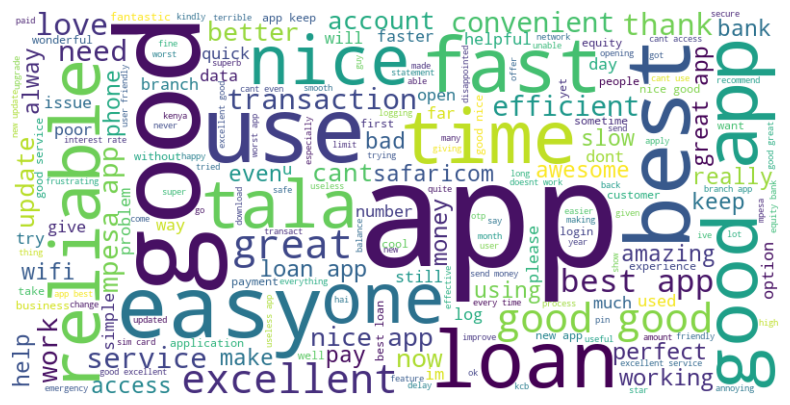

In [35]:


text = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


Frequently occurring words appear larger in the visualization.

 Positive sentiment words dominate the dataset.

 The visualization confirms the insights from word frequency analysis


### Time and Trend Exploratory Analysis
In this section we check the following trends:
- overall fintech review activity over time
- complaint trends over time
- complaint spikes
- monthly complaint rates
- financial distress patterns within Kenya’s mobile money ecosystem

The overal review trends and and complaint trends will provide a more complete picture of customer experience and financial distress.

In [ ]:
# Convert review dates to datetime

df['at'] = pd.to_datetime(
    df['at'],
    errors='coerce'
)

# Create year-month column

df['year_month'] = df['at'].dt.to_period('M')

# Create complaint indicator
# Ratings <= 2 are treated as complaints

df['is_complaint'] = df['score'].apply(
    lambda x: 1 if x <= 2 else 0
)

df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name,year_month,is_complaint
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa,2026-05,1
1,acd5c061-de13-474b-8645-f628044f2a50,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa,2026-05,1
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa,2026-05,1
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa,2026-05,1
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,NaN,mpesa,2026-05,1


In [40]:
# Monthly summary of reviews, complaints, and average ratings
monthly_summary = (
    df.groupby('year_month')
    .agg(
        total_reviews=('content', 'count'),
        complaints=('is_complaint', 'sum'),
        average_rating=('score', 'mean')
    )
    .reset_index()
)

# Complaint rate

monthly_summary['complaint_rate'] = (
    monthly_summary['complaints']
    /
    monthly_summary['total_reviews']
)

# Rolling average of complaints

monthly_summary['rolling_avg_complaints'] = (
    monthly_summary['complaints']
    .rolling(window=3)
    .mean()
)

In this section we calculate a **z-score for monthly complaint counts** to measure how far each month deviates from the average complaint level to identify **months with unusually high complaint activity (z-score > 2)**, which are considered statistical anomalies or complaint spikes,it outputs only the months where complaint levels are significantly higher than normal, helping to detect extreme events in the fintech ecosystem.


In [41]:
# Z-score calculation

monthly_summary['z_score'] = (
    (
        monthly_summary['complaints']
        - monthly_summary['complaints'].mean()
    )
    /
    monthly_summary['complaints'].std()
)

# Months with abnormal complaint spikes

complaint_spikes = monthly_summary[
    monthly_summary['z_score'] > 2
]

complaint_spikes

,year_month,total_reviews,complaints,average_rating,complaint_rate,rolling_avg_complaints,z_score
35,2026-04,12766,4285,3.55687,0.335657,1694.666667,5.684279


The z-score of **5.666402** is far above the threshold of 2, indicating that April 2026 was an **extreme outlier** in complaint activity.

This confirms a statistically significant spike in customer dissatisfaction, likely driven by major disruptions such as:
- system outages
- transaction failures
- fraud-related incidents
- sudden economic or platform stress events


#### Visualizations for monthly review trends and monthly complaints
The overall monthly review trend graph shows how customer feedback activity within Kenya’s fintech ecosystem changed over time between 2023 and 2026.


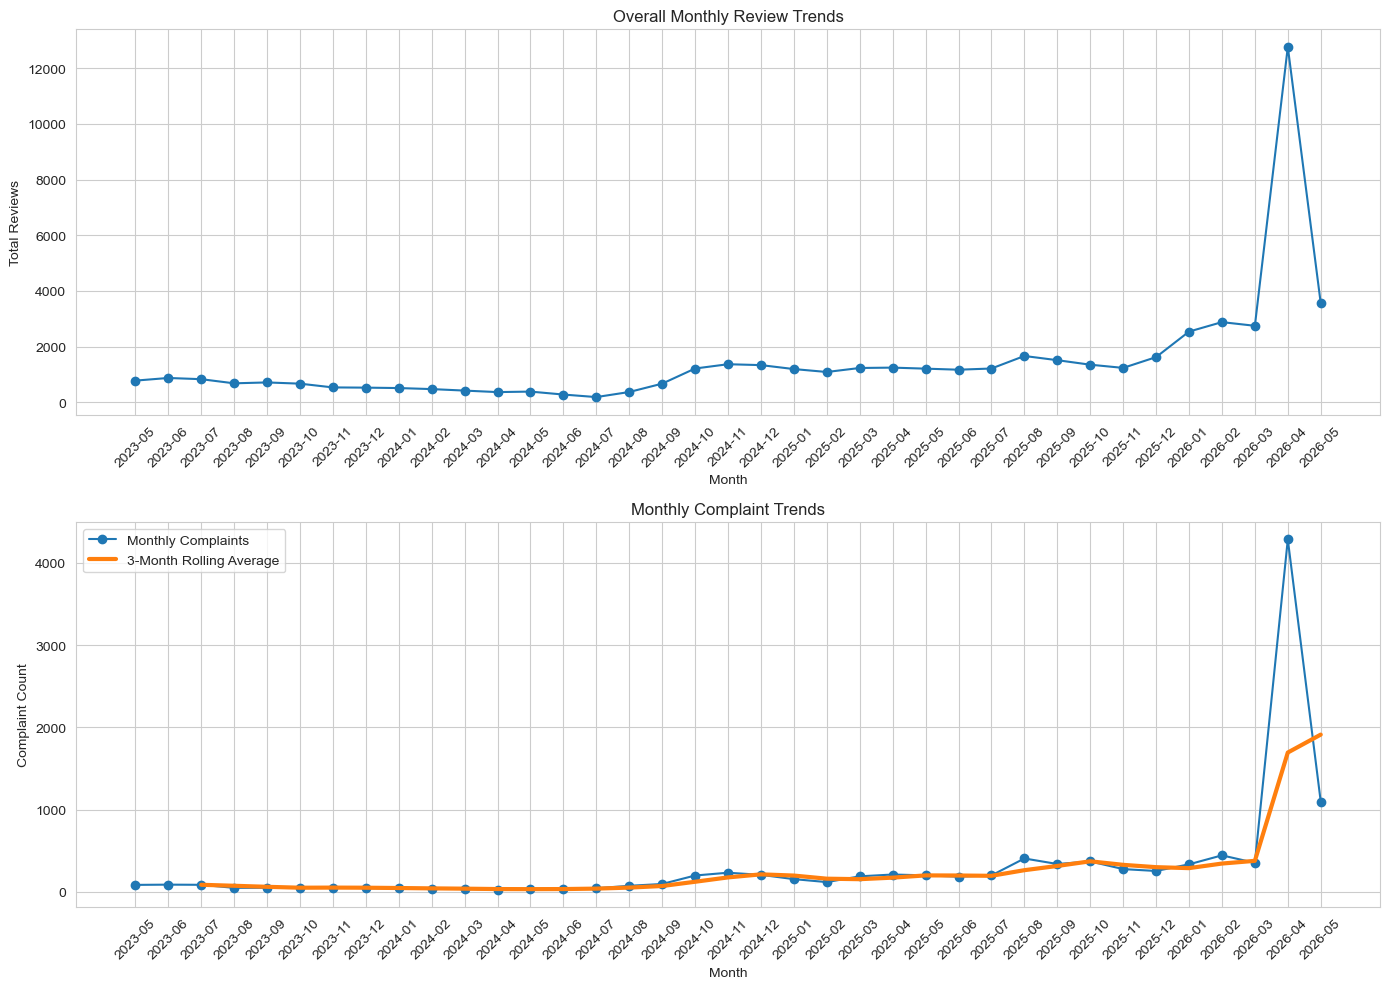

In [42]:
# Create visualizations
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14,10)
)


# GRAPH 1 — OVERALL MONTHLY REVIEW TRENDS


axes[0].plot(
    monthly_summary['year_month'].astype(str),
    monthly_summary['total_reviews'],
    marker='o'
)

axes[0].set_title("Overall Monthly Review Trends")

axes[0].set_xlabel("Month")

axes[0].set_ylabel("Total Reviews")

axes[0].tick_params(axis='x', rotation=45)

axes[0].grid(True)


# Graph 2 — MONTHLY COMPLAINT TRENDS WITH ROLLING AVERAGE


axes[1].plot(
    monthly_summary['year_month'].astype(str),
    monthly_summary['complaints'],
    marker='o',
    label='Monthly Complaints'
)

axes[1].plot(
    monthly_summary['year_month'].astype(str),
    monthly_summary['rolling_avg_complaints'],
    linewidth=3,
    label='3-Month Rolling Average'
)

axes[1].set_title("Monthly Complaint Trends")

axes[1].set_xlabel("Month")

axes[1].set_ylabel("Complaint Count")

axes[1].tick_params(axis='x', rotation=45)

axes[1].legend()

axes[1].grid(True)

#Add tight layout to prevent overlap
plt.tight_layout()

plt.show()

#### Summary of Review and Complaint Trends

Customer review and complaint activity within Kenya’s fintech ecosystem remained relatively stable during 2023 and early 2024 but increased steadily from late 2024 onward, indicating rising user dissatisfaction and growing pressure on digital financial services.

A major spike occurred in April 2026, with record-high reviews and complaints, likely linked to service disruptions, fraud concerns, or transaction failures.

Although activity declined slightly afterward, complaint levels remained elevated, highlighting the need for real-time complaint monitoring and stronger consumer protection measures by fintech firms and regulators

#### Monthly Complaint Trend Summary
The table highlights the months with the highest complaint rates within the Kenyan fintech review dataset. Complaint rate measures the proportion of reviews classified as complaints relative to the total number of reviews in a given month.


In [43]:
#Identify top 10 months with highest complaint rates
monthly_summary.sort_values(
    by='complaint_rate',
    ascending=False
).head(10)

,year_month,total_reviews,complaints,average_rating,complaint_rate,rolling_avg_complaints,z_score
35,2026-04,12766,4285,3.556870,0.335657,1694.666667,5.684279
36,2026-05,3562,1099,3.693711,0.308535,1912.666667,1.141557
29,2025-10,1353,371,3.767923,0.274205,372.666667,0.103547
27,2025-08,1666,407,3.863145,0.244298,264.666667,0.154877
14,2024-07,190,45,3.968421,0.236842,40.666667,-0.361277
30,2025-11,1238,278,3.928918,0.224556,329.666667,-0.029056
28,2025-09,1515,340,3.936634,0.224422,316.000000,0.059346
15,2024-08,372,75,4.029570,0.201613,53.000000,-0.318502
18,2024-11,1370,234,4.124818,0.170803,177.000000,-0.091793
23,2025-04,1248,212,4.161058,0.169872,174.000000,-0.123162


#### Key Findings

- **April 2026** recorded the highest financial distress indicators, with extremely high complaint volumes, high complaint rates, lower average ratings, and the highest z-score in the dataset. The high z-score indicates that complaint activity during this period was far above normal levels and represents a major anomaly.

- **May 2026** showed a slight decline in complaints, but dissatisfaction remained elevated, while the rolling average and z-score remained high, suggesting continued pressure within the fintech ecosystem.

- **Late 2025** experienced consistently high complaint activity, indicating prolonged customer dissatisfaction possibly linked to increased transaction volumes, financial stress, or platform reliability issues.

- Higher complaint months generally corresponded with lower average ratings, showing a strong relationship between complaints, customer dissatisfaction, and reduced service quality.